# MNIST Classification: Paper Plots for SVD-SGD

This notebook generates publication-quality plots for the SVD-SGD optimizer paper, focusing on MNIST classification.

## Contents
1. **Setup & Data Loading** - Load all experiment files, combine into unified DataFrame
2. **Optimizer Comparison** - SVD vs standard optimizers (accuracy & loss)
3. **Hyperparameter Sensitivity** - Learning rate, batch size, k
4. **MLP Width Analysis** - Impact of network capacity
5. **Singular Value Analysis** - Spectrum visualization and effective rank
6. **Summary & Interpretation**

## 1. Setup & Data Loading

In [27]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from glob import glob
import re
import warnings
warnings.filterwarnings('ignore')

# Paper-quality plot settings
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (8, 8),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 2,
    'axes.grid': False,
    'grid.alpha': 0.3,
    'font.family': 'arial',
    'legend.frameon': False
})

# Output directory for plots
PLOT_DIR = Path('plots/mnist')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved to: {PLOT_DIR.absolute()}")

Plots will be saved to: /Users/sambt/iaifi/sv3/claude_experiments/plots/mnist


In [28]:
# Load all experiment results and combine into single DataFrame
RESULTS_DIR = Path('../experiment_results/mnist_scan')

all_dfs = []
file_pattern = 'mnist_scan_results_bs*_width*_df.pkl'

for filepath in sorted(RESULTS_DIR.glob(file_pattern)):
    # Extract batch_size and width from filename
    match = re.search(r'bs(\d+)_width(\d+)', filepath.name)
    if match:
        bs_from_name = int(match.group(1))
        width_from_name = int(match.group(2))
        
        with open(filepath, 'rb') as f:
            df_temp = pickle.load(f)
        
        # Ensure batch_size and mlp_width columns exist
        if 'batch_size' not in df_temp.columns:
            df_temp['batch_size'] = bs_from_name
        if 'mlp_width' not in df_temp.columns:
            df_temp['mlp_width'] = width_from_name
            
        all_dfs.append(df_temp)
        print(f"Loaded {filepath.name}: {len(df_temp)} rows")

df = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal: {len(df)} experiment runs")
print(f"\nColumns: {df.columns.tolist()}")

Loaded mnist_scan_results_bs128_width128_df.pkl: 24 rows
Loaded mnist_scan_results_bs128_width32_df.pkl: 24 rows
Loaded mnist_scan_results_bs128_width64_df.pkl: 24 rows
Loaded mnist_scan_results_bs256_width128_df.pkl: 24 rows
Loaded mnist_scan_results_bs256_width32_df.pkl: 24 rows
Loaded mnist_scan_results_bs256_width64_df.pkl: 24 rows
Loaded mnist_scan_results_bs32_width128_df.pkl: 24 rows
Loaded mnist_scan_results_bs32_width32_df.pkl: 24 rows
Loaded mnist_scan_results_bs32_width64_df.pkl: 24 rows
Loaded mnist_scan_results_bs64_width128_df.pkl: 24 rows
Loaded mnist_scan_results_bs64_width32_df.pkl: 24 rows
Loaded mnist_scan_results_bs64_width64_df.pkl: 24 rows

Total: 288 experiment runs

Columns: ['batch_size', 'k_fraction', 'k', 'lr', 'mlp_width', 'losses', 'svd_info', 'optimizer']


In [29]:
# Examine unique values
print("Unique values:")
print(f"  Optimizers: {df['optimizer'].unique()}")
print(f"  Batch sizes: {sorted(df['batch_size'].unique())}")
print(f"  MLP widths: {sorted(df['mlp_width'].unique())}")
print(f"  Learning rates: {sorted(df['lr'].unique())}")
print(f"\nSVD runs: {len(df[df['optimizer']=='SVD'])}")
print(f"Baseline runs: {len(df[df['optimizer']!='SVD'])}")

Unique values:
  Optimizers: ['SVD' 'Adam' 'AdamW' 'SGD' 'RMSprop']
  Batch sizes: [32, 64, 128, 256]
  MLP widths: [32, 64, 128]
  Learning rates: [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]

SVD runs: 144
Baseline runs: 144


In [30]:
# Separate SVD and baseline results
df_svd = df[df['optimizer'] == 'SVD'].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()

# Extract unique hyperparameters
batch_sizes = sorted(df['batch_size'].unique())
mlp_widths = sorted(df['mlp_width'].unique())
k_fractions = sorted(df_svd['k_fraction'].dropna().unique())
svd_lrs = sorted(df_svd['lr'].unique())
baseline_lrs = sorted(df_baseline['lr'].unique())
baseline_optimizers = df_baseline['optimizer'].unique().tolist()

print("SVD Hyperparameters:")
print(f"  k_fractions: {k_fractions}")
print(f"  Learning rates: {svd_lrs}")
print(f"\nBaseline Hyperparameters:")
print(f"  Optimizers: {baseline_optimizers}")
print(f"  Learning rates: {baseline_lrs}")
print(f"\nMLP Widths: {mlp_widths}")
print(f"Batch Sizes: {batch_sizes}")

SVD Hyperparameters:
  k_fractions: [0.25, 0.5, 0.75, 1.0]
  Learning rates: [0.1, 0.5, 1.0]

Baseline Hyperparameters:
  Optimizers: ['Adam', 'AdamW', 'SGD', 'RMSprop']
  Learning rates: [0.0001, 0.001, 0.01]

MLP Widths: [32, 64, 128]
Batch Sizes: [32, 64, 128, 256]


In [31]:
# Helper functions
def get_final_loss(row, loss_type='val'):
    """Get final epoch loss."""
    return row['losses'][loss_type][-1]

def get_final_acc(row, acc_type='val_acc'):
    """Get final epoch accuracy."""
    if acc_type in row['losses']:
        return row['losses'][acc_type][-1]
    return np.nan

def get_loss_curve(row, loss_type='val'):
    """Get per-epoch loss curve."""
    return np.array(row['losses'][loss_type])

def get_acc_curve(row, acc_type='val_acc'):
    """Get per-epoch accuracy curve."""
    if acc_type in row['losses']:
        return np.array(row['losses'][acc_type])
    return None

def get_svd_info(row):
    """Get SVD singular values and counts."""
    if row['svd_info'] is None or (isinstance(row['svd_info'], float) and pd.isna(row['svd_info'])):
        return None, None
    return row['svd_info'].get('svs'), row['svd_info'].get('num_nonzero_svs')

def sliding_average(data, window=10):
    """Compute sliding average for smoothing."""
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Add derived columns
df['final_val_loss'] = df.apply(lambda r: get_final_loss(r, 'val'), axis=1)
df['final_train_loss'] = df.apply(lambda r: get_final_loss(r, 'train'), axis=1)
df['final_val_acc'] = df.apply(lambda r: get_final_acc(r, 'val_acc'), axis=1)
df['final_train_acc'] = df.apply(lambda r: get_final_acc(r, 'train_acc'), axis=1)

df_svd = df[df['optimizer'] == 'SVD'].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()

print("Added final_val_loss, final_train_loss, final_val_acc, final_train_acc columns")
print(f"\nValidation accuracy range: {df['final_val_acc'].min():.3f} - {df['final_val_acc'].max():.3f}")

Added final_val_loss, final_train_loss, final_val_acc, final_train_acc columns

Validation accuracy range: 0.098 - 0.982


## 2. Optimizer Comparison

### 2.1 Best Performance Comparison (Loss)

In [32]:
# Find best run for each optimizer type (by validation accuracy)
best_runs = []

# Best SVD
best_svd_idx = df_svd['final_val_loss'].idxmax()
best_svd = df_svd.loc[best_svd_idx]
best_runs.append({
    'optimizer': 'SVD',
    'final_val_loss': best_svd['final_val_loss'],
    'lr': best_svd['lr'],
    'batch_size': best_svd['batch_size'],
    'mlp_width': best_svd['mlp_width'],
    'k': best_svd.get('k', None),
    'k_fraction': best_svd.get('k_fraction', None)
})

# Best for each baseline optimizer
for opt in baseline_optimizers:
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best_idx = opt_df['final_val_loss'].idxmax()
    best = opt_df.loc[best_idx]
    best_runs.append({
        'optimizer': opt,
        'final_val_loss': best['final_val_loss'],
        'lr': best['lr'],
        'batch_size': best['batch_size'],
        'mlp_width': best['mlp_width'],
        'k': None,
        'k_fraction': None
    })

best_df = pd.DataFrame(best_runs)
print("Best performance for each optimizer (by validation accuracy):")
print(best_df.to_string(index=False))

Best performance for each optimizer (by validation accuracy):
optimizer  final_val_loss     lr  batch_size  mlp_width    k  k_fraction
      SVD        0.713362 1.0000         256         32 64.0        0.25
     Adam        0.267603 0.0100          32        128  NaN         NaN
    AdamW        0.202369 0.0100          64        128  NaN         NaN
      SGD        2.308442 0.0001         256         32  NaN         NaN
  RMSprop        0.881480 0.0100          32        128  NaN         NaN


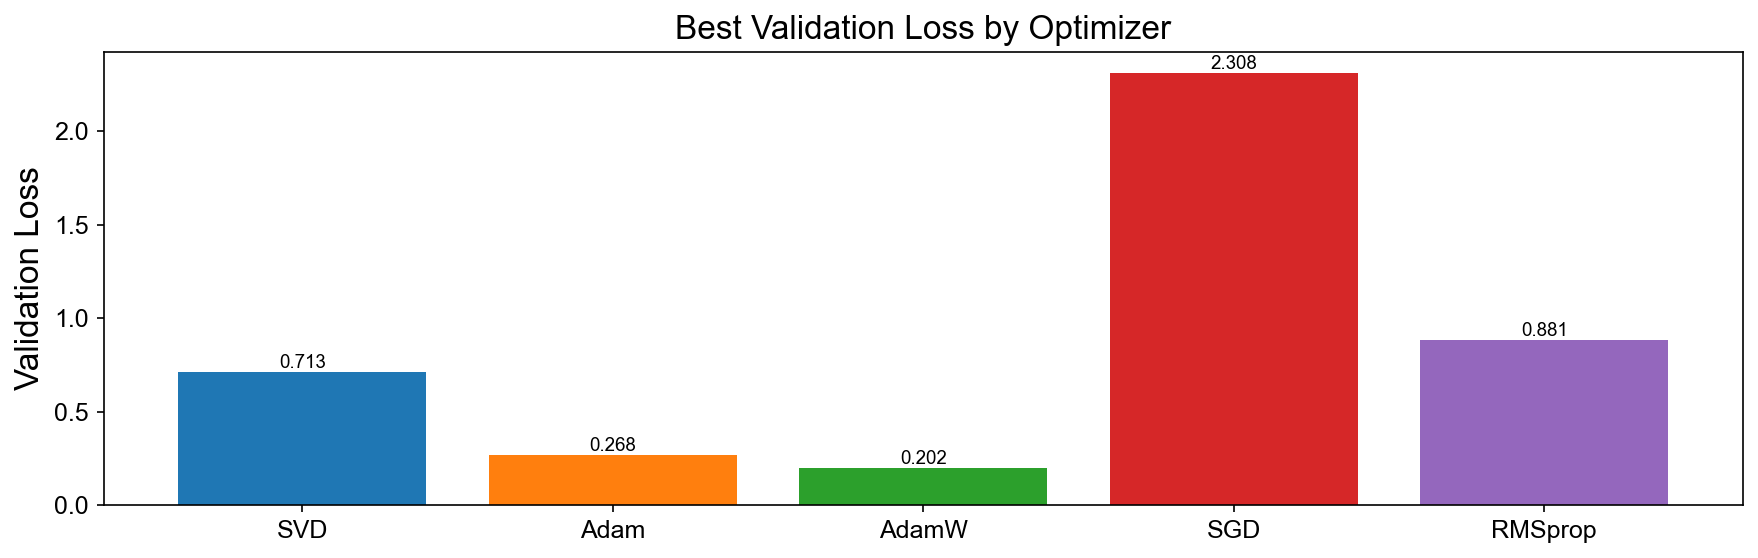

In [33]:
# Plot: Best final validation accuracy by optimizer
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

colors = ['C0', 'C1', 'C2', 'C3', 'C4']
x = np.arange(len(best_df))

# Loss
bars = ax.bar(x, best_df['final_val_loss'], color=colors)
ax.set_xticks(x)
ax.set_xticklabels(best_df['optimizer'])
ax.set_ylabel('Validation Loss')
ax.set_title('Best Validation Loss by Optimizer')

for bar, val in zip(bars, best_df['final_val_loss']):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}', 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'best_optimizer_comparison.pdf')
plt.savefig(PLOT_DIR / 'best_optimizer_comparison.png')
plt.show()

### 2.2 Training Curves: Best Configurations

KeyError: nan

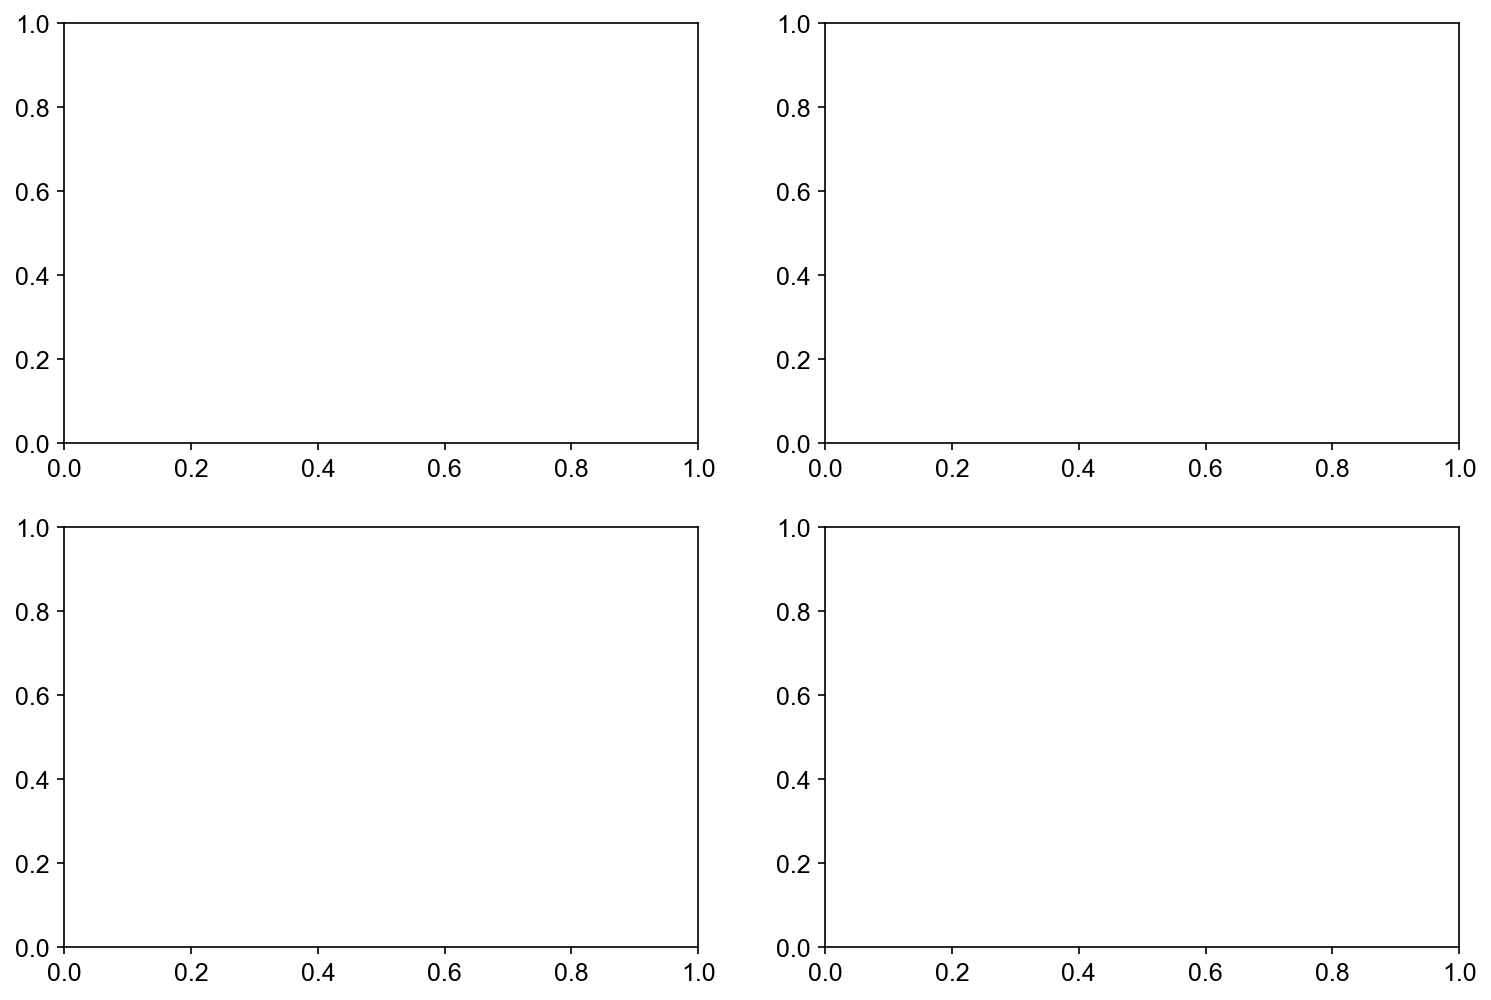

In [34]:
# Plot training curves for best configuration of each optimizer
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

best_svd_row = df.loc[df_svd['final_val_acc'].idxmax()]
epochs = np.arange(1, len(get_loss_curve(best_svd_row, 'train')) + 1)

# Training loss
ax = axes[0, 0]
ax.plot(epochs, get_loss_curve(best_svd_row, 'train'), 'C0-', linewidth=2,
        label=f"SVD (lr={best_svd_row['lr']}, k={int(best_svd_row['k'])})")
for i, opt in enumerate(baseline_optimizers):
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best_row = df.loc[opt_df['final_val_acc'].idxmax()]
    ax.plot(epochs, get_loss_curve(best_row, 'train'), f'C{i+1}--',
            label=f"{opt} (lr={best_row['lr']:.0e})")
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss')
ax.legend(loc='upper right', fontsize=8)

# Validation loss
ax = axes[0, 1]
ax.plot(epochs, get_loss_curve(best_svd_row, 'val'), 'C0-', linewidth=2,
        label=f"SVD")
for i, opt in enumerate(baseline_optimizers):
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best_row = df.loc[opt_df['final_val_acc'].idxmax()]
    ax.plot(epochs, get_loss_curve(best_row, 'val'), f'C{i+1}--', label=opt)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Loss')
ax.legend(loc='upper right', fontsize=8)

# Training accuracy
ax = axes[1, 0]
train_acc = get_acc_curve(best_svd_row, 'train_acc')
if train_acc is not None:
    ax.plot(epochs, train_acc * 100, 'C0-', linewidth=2, label='SVD')
for i, opt in enumerate(baseline_optimizers):
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best_row = df.loc[opt_df['final_val_acc'].idxmax()]
    acc = get_acc_curve(best_row, 'train_acc')
    if acc is not None:
        ax.plot(epochs, acc * 100, f'C{i+1}--', label=opt)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Accuracy (%)')
ax.set_title('Training Accuracy')
ax.legend(loc='lower right', fontsize=8)

# Validation accuracy
ax = axes[1, 1]
val_acc = get_acc_curve(best_svd_row, 'val_acc')
if val_acc is not None:
    ax.plot(epochs, val_acc * 100, 'C0-', linewidth=2, label='SVD')
for i, opt in enumerate(baseline_optimizers):
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best_row = df.loc[opt_df['final_val_acc'].idxmax()]
    acc = get_acc_curve(best_row, 'val_acc')
    if acc is not None:
        ax.plot(epochs, acc * 100, f'C{i+1}--', label=opt)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Validation Accuracy')
ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Training Curves (Best Configurations)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'training_curves_best.pdf')
plt.savefig(PLOT_DIR / 'training_curves_best.png')
plt.show()

## 3. Hyperparameter Sensitivity

### 3.1 Heatmap: Accuracy vs Hyperparameters

In [ ]:
# Heatmap of final validation accuracy for SVD optimizer
# For each (batch_size, mlp_width), show k_fraction vs learning rate

fig, axes = plt.subplots(len(batch_sizes), len(mlp_widths), 
                          figsize=(3.5*len(mlp_widths), 3*len(batch_sizes)))

for i, bs in enumerate(batch_sizes):
    for j, width in enumerate(mlp_widths):
        ax = axes[i, j] if len(batch_sizes) > 1 else axes[j]
        
        # Filter data
        data = df_svd[(df_svd['batch_size'] == bs) & (df_svd['mlp_width'] == width)]
        
        if len(data) > 0:
            pivot = data.pivot_table(
                values='final_val_acc', 
                index='k_fraction', 
                columns='lr',
                aggfunc='first'
            )
            
            im = ax.imshow(pivot.values * 100, aspect='auto', cmap='RdYlGn',
                           vmin=85, vmax=98)
            
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([f'{lr}' for lr in pivot.columns], rotation=45)
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels([f'{kf}' for kf in pivot.index])
            
            if i == len(batch_sizes) - 1:
                ax.set_xlabel('Learning Rate')
            if j == 0:
                ax.set_ylabel('k / batch_size')
            ax.set_title(f'bs={bs}, width={width}')
            
            # Add text annotations
            for ii in range(len(pivot.index)):
                for jj in range(len(pivot.columns)):
                    val = pivot.values[ii, jj] * 100
                    color = 'white' if val < 92 else 'black'
                    ax.text(jj, ii, f'{val:.1f}', ha='center', va='center', 
                           fontsize=7, color=color)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Validation Accuracy (%)')

plt.suptitle('SVD Optimizer: Validation Accuracy', fontsize=14, y=1.02)
plt.savefig(PLOT_DIR / 'svd_heatmap_accuracy.pdf', bbox_inches='tight')
plt.savefig(PLOT_DIR / 'svd_heatmap_accuracy.png', bbox_inches='tight')
plt.show()

### 3.2 Learning Rate Sensitivity

In [ ]:
# Learning rate sensitivity across configurations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SVD: fixed width, vary k_fraction
ax = axes[0]
fixed_width = 64
fixed_bs = 64

for i, kf in enumerate(k_fractions):
    data = df_svd[(df_svd['mlp_width'] == fixed_width) & 
                   (df_svd['batch_size'] == fixed_bs) &
                   (df_svd['k_fraction'] == kf)].sort_values('lr')
    if len(data) > 0:
        ax.plot(data['lr'], data['final_val_acc'] * 100, 'o-', 
                label=f'k/bs={kf}', color=f'C{i}')

ax.set_xlabel('Learning Rate')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title(f'SVD LR Sensitivity (bs={fixed_bs}, width={fixed_width})')
ax.set_xscale('log')
ax.legend()

# Baseline optimizers
ax = axes[1]
for i, opt in enumerate(baseline_optimizers):
    data = df_baseline[(df_baseline['optimizer'] == opt) & 
                        (df_baseline['mlp_width'] == fixed_width) &
                        (df_baseline['batch_size'] == fixed_bs)].sort_values('lr')
    if len(data) > 0:
        ax.plot(data['lr'], data['final_val_acc'] * 100, 's--', 
                label=opt, color=f'C{i}')

ax.set_xlabel('Learning Rate')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title(f'Baseline LR Sensitivity (bs={fixed_bs}, width={fixed_width})')
ax.set_xscale('log')
ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'lr_sensitivity.pdf')
plt.savefig(PLOT_DIR / 'lr_sensitivity.png')
plt.show()

## 4. MLP Width Analysis

How does network capacity (MLP width) affect SVD optimizer performance?

### 4.1 Best Performance vs MLP Width

In [ ]:
# Best accuracy for each optimizer at each width
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot best accuracy vs width
ax = axes[0]

# SVD best per width
svd_best_by_width = df_svd.groupby('mlp_width')['final_val_acc'].max()
ax.plot(svd_best_by_width.index, svd_best_by_width.values * 100, 'o-', 
        label='SVD', linewidth=2, markersize=8, color='C0')

# Baseline best per width
for i, opt in enumerate(baseline_optimizers):
    opt_data = df_baseline[df_baseline['optimizer'] == opt]
    opt_best = opt_data.groupby('mlp_width')['final_val_acc'].max()
    ax.plot(opt_best.index, opt_best.values * 100, 's--', 
            label=opt, color=f'C{i+1}')

ax.set_xlabel('MLP Width')
ax.set_ylabel('Best Validation Accuracy (%)')
ax.set_title('Best Accuracy vs Network Width')
ax.legend()
ax.set_xticks(mlp_widths)

# Plot best loss vs width
ax = axes[1]

# For loss, take min
svd_best_loss = df_svd.groupby('mlp_width')['final_val_loss'].min()
ax.plot(svd_best_loss.index, svd_best_loss.values, 'o-', 
        label='SVD', linewidth=2, markersize=8, color='C0')

for i, opt in enumerate(baseline_optimizers):
    opt_data = df_baseline[df_baseline['optimizer'] == opt]
    opt_best = opt_data.groupby('mlp_width')['final_val_loss'].min()
    ax.plot(opt_best.index, opt_best.values, 's--', 
            label=opt, color=f'C{i+1}')

ax.set_xlabel('MLP Width')
ax.set_ylabel('Best Validation Loss')
ax.set_title('Best Loss vs Network Width')
ax.legend()
ax.set_xticks(mlp_widths)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'width_effect_best.pdf')
plt.savefig(PLOT_DIR / 'width_effect_best.png')
plt.show()

### 4.2 MLP Width Effect on SVD Hyperparameter Sensitivity

In [ ]:
# How does width affect optimal k_fraction and lr?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fixed_bs = 64

# For each width, plot accuracy vs k_fraction at best lr
ax = axes[0]
for i, width in enumerate(mlp_widths):
    # Find best lr for this width
    width_data = df_svd[(df_svd['mlp_width'] == width) & (df_svd['batch_size'] == fixed_bs)]
    best_lr = width_data.loc[width_data['final_val_acc'].idxmax(), 'lr']
    
    data = width_data[width_data['lr'] == best_lr].sort_values('k_fraction')
    ax.plot(data['k_fraction'], data['final_val_acc'] * 100, 'o-', 
            label=f'width={width} (lr={best_lr})', color=f'C{i}')

ax.set_xlabel('k / batch_size')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title(f'k_fraction Effect by Width (bs={fixed_bs})')
ax.legend()

# For each width, plot accuracy vs lr at best k_fraction
ax = axes[1]
for i, width in enumerate(mlp_widths):
    width_data = df_svd[(df_svd['mlp_width'] == width) & (df_svd['batch_size'] == fixed_bs)]
    best_kf = width_data.loc[width_data['final_val_acc'].idxmax(), 'k_fraction']
    
    data = width_data[width_data['k_fraction'] == best_kf].sort_values('lr')
    ax.plot(data['lr'], data['final_val_acc'] * 100, 'o-', 
            label=f'width={width} (k/bs={best_kf})', color=f'C{i}')

ax.set_xlabel('Learning Rate')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title(f'LR Effect by Width (bs={fixed_bs})')
ax.set_xscale('log')
ax.legend()

# Training curves for best config at each width
ax = axes[2]
for i, width in enumerate(mlp_widths):
    width_data = df_svd[(df_svd['mlp_width'] == width) & (df_svd['batch_size'] == fixed_bs)]
    best_idx = width_data['final_val_acc'].idxmax()
    best_row = df.loc[best_idx]
    
    acc_curve = get_acc_curve(best_row, 'val_acc')
    if acc_curve is not None:
        epochs = np.arange(1, len(acc_curve) + 1)
        ax.plot(epochs, acc_curve * 100, '-', 
                label=f'width={width}', color=f'C{i}', linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title(f'Training Progress by Width (bs={fixed_bs})')
ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'width_hyperparameter_interaction.pdf')
plt.savefig(PLOT_DIR / 'width_hyperparameter_interaction.png')
plt.show()

### 4.3 Width vs Batch Size Interaction

In [ ]:
# Heatmap: best accuracy for each (batch_size, width) combination
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SVD
ax = axes[0]
svd_pivot = df_svd.groupby(['batch_size', 'mlp_width'])['final_val_acc'].max().unstack()
im = ax.imshow(svd_pivot.values * 100, aspect='auto', cmap='RdYlGn', vmin=90, vmax=98)
ax.set_xticks(range(len(svd_pivot.columns)))
ax.set_xticklabels(svd_pivot.columns)
ax.set_yticks(range(len(svd_pivot.index)))
ax.set_yticklabels(svd_pivot.index)
ax.set_xlabel('MLP Width')
ax.set_ylabel('Batch Size')
ax.set_title('SVD: Best Accuracy')

for i in range(len(svd_pivot.index)):
    for j in range(len(svd_pivot.columns)):
        val = svd_pivot.values[i, j] * 100
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=10)

plt.colorbar(im, ax=ax, label='Accuracy (%)')

# Best baseline (across all baseline optimizers)
ax = axes[1]
baseline_pivot = df_baseline.groupby(['batch_size', 'mlp_width'])['final_val_acc'].max().unstack()
im = ax.imshow(baseline_pivot.values * 100, aspect='auto', cmap='RdYlGn', vmin=90, vmax=98)
ax.set_xticks(range(len(baseline_pivot.columns)))
ax.set_xticklabels(baseline_pivot.columns)
ax.set_yticks(range(len(baseline_pivot.index)))
ax.set_yticklabels(baseline_pivot.index)
ax.set_xlabel('MLP Width')
ax.set_ylabel('Batch Size')
ax.set_title('Baseline (Best): Best Accuracy')

for i in range(len(baseline_pivot.index)):
    for j in range(len(baseline_pivot.columns)):
        val = baseline_pivot.values[i, j] * 100
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=10)

plt.colorbar(im, ax=ax, label='Accuracy (%)')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'width_batchsize_heatmap.pdf')
plt.savefig(PLOT_DIR / 'width_batchsize_heatmap.png')
plt.show()

### 4.4 Number of Parameters vs Performance

In [ ]:
# Calculate number of parameters for each width
# MLP: 784 -> width -> width -> width -> 10
def calc_params(width):
    # Layer 1: 784 * width + width (bias)
    # Layer 2: width * width + width
    # Layer 3: width * width + width
    # Layer 4: width * 10 + 10
    return (784 * width + width) + (width * width + width) * 2 + (width * 10 + 10)

param_counts = {w: calc_params(w) for w in mlp_widths}
print("Parameter counts by width:")
for w, p in param_counts.items():
    print(f"  width={w}: {p:,} parameters")

# Plot accuracy vs number of parameters
fig, ax = plt.subplots(figsize=(8, 5))

# SVD
svd_best = df_svd.groupby('mlp_width')['final_val_acc'].max()
x_svd = [param_counts[w] for w in svd_best.index]
ax.plot(x_svd, svd_best.values * 100, 'o-', label='SVD', linewidth=2, markersize=10, color='C0')

# Baselines
for i, opt in enumerate(baseline_optimizers):
    opt_data = df_baseline[df_baseline['optimizer'] == opt]
    opt_best = opt_data.groupby('mlp_width')['final_val_acc'].max()
    x_opt = [param_counts[w] for w in opt_best.index]
    ax.plot(x_opt, opt_best.values * 100, 's--', label=opt, color=f'C{i+1}')

ax.set_xlabel('Number of Parameters')
ax.set_ylabel('Best Validation Accuracy (%)')
ax.set_title('Accuracy vs Model Size')
ax.legend()
ax.set_xscale('log')

# Add width annotations
for w in mlp_widths:
    ax.axvline(x=param_counts[w], color='gray', linestyle=':', alpha=0.5)
    ax.text(param_counts[w], ax.get_ylim()[1], f'w={w}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'accuracy_vs_params.pdf')
plt.savefig(PLOT_DIR / 'accuracy_vs_params.png')
plt.show()

## 5. Singular Value Analysis

### 5.1 Effective Rank vs MLP Width

In [ ]:
# Compare effective rank across widths
fig, axes = plt.subplots(1, len(mlp_widths), figsize=(5*len(mlp_widths), 4))

fixed_bs = 64
fixed_lr = 0.5
fixed_kf = 1.0

for ax, width in zip(axes, mlp_widths):
    data = df_svd[(df_svd['mlp_width'] == width) & 
                   (df_svd['batch_size'] == fixed_bs) &
                   (df_svd['lr'] == fixed_lr) &
                   (df_svd['k_fraction'] == fixed_kf)]
    
    if len(data) > 0:
        row = data.iloc[0]
        _, num_nonzero = get_svd_info(row)
        
        if num_nonzero is not None:
            batches = np.arange(len(num_nonzero))
            window = 20
            
            ax.plot(batches, num_nonzero, alpha=0.3, color='C0')
            if len(num_nonzero) > window:
                smoothed = sliding_average(num_nonzero, window)
                ax.plot(batches[window-1:], smoothed, color='C0', linewidth=2)
            
            ax.axhline(y=row['k'], color='red', linestyle='--', label=f'Max k={int(row["k"])}')
            ax.set_xlabel('Batch')
            ax.set_ylabel('# Nonzero SVs')
            ax.set_title(f'Width = {width}')
            ax.legend(loc='lower right')

plt.suptitle(f'Effective Rank During Training (bs={fixed_bs}, lr={fixed_lr}, k/bs={fixed_kf})', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'effective_rank_by_width.pdf')
plt.savefig(PLOT_DIR / 'effective_rank_by_width.png')
plt.show()

### 5.2 Average Effective Rank Summary

In [ ]:
# Compute average effective rank for all SVD runs
eff_rank_data = []

for idx, row in df_svd.iterrows():
    _, num_nonzero = get_svd_info(row)
    if num_nonzero is not None:
        eff_rank_data.append({
            'batch_size': row['batch_size'],
            'mlp_width': row['mlp_width'],
            'k': row['k'],
            'k_fraction': row['k_fraction'],
            'lr': row['lr'],
            'final_val_acc': row['final_val_acc'],
            'avg_eff_rank': np.mean(num_nonzero),
            'eff_rank_ratio': np.mean(num_nonzero) / row['k'] if row['k'] > 0 else 0
        })

eff_rank_df = pd.DataFrame(eff_rank_data)

# Plot effective rank ratio by width
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for i, width in enumerate(mlp_widths):
    width_data = eff_rank_df[eff_rank_df['mlp_width'] == width]
    ax.scatter(width_data['avg_eff_rank'], width_data['final_val_acc'] * 100, 
               label=f'width={width}', alpha=0.7, color=f'C{i}')

ax.set_xlabel('Average Effective Rank')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Accuracy vs Effective Rank (by Width)')
ax.legend()

ax = axes[1]
# Average effective rank ratio by width
width_summary = eff_rank_df.groupby('mlp_width').agg({
    'eff_rank_ratio': 'mean',
    'avg_eff_rank': 'mean'
}).reset_index()

ax.bar(range(len(width_summary)), width_summary['eff_rank_ratio'], 
       tick_label=width_summary['mlp_width'], color='C0', alpha=0.7)
ax.set_xlabel('MLP Width')
ax.set_ylabel('Avg Effective Rank / k')
ax.set_title('Normalized Effective Rank by Width')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'effective_rank_summary.pdf')
plt.savefig(PLOT_DIR / 'effective_rank_summary.png')
plt.show()

## 6. Summary

In [ ]:
# Summary statistics
print("=" * 70)
print("MNIST CLASSIFICATION SUMMARY")
print("=" * 70)

print("\nBest performance by optimizer:")
print(best_df[['optimizer', 'final_val_acc', 'lr', 'batch_size', 'mlp_width', 'k']].to_string(index=False))

print("\n" + "-" * 70)
print("\nBest accuracy by MLP width:")
for width in mlp_widths:
    svd_acc = df_svd[df_svd['mlp_width'] == width]['final_val_acc'].max()
    baseline_acc = df_baseline[df_baseline['mlp_width'] == width]['final_val_acc'].max()
    print(f"  Width {width}: SVD={svd_acc*100:.2f}%, Baseline={baseline_acc*100:.2f}%")

print("\n" + "-" * 70)
print("\nParameter counts:")
for w, p in param_counts.items():
    print(f"  Width {w}: {p:,} parameters")

In [ ]:
print(f"\nAll plots saved to: {PLOT_DIR.absolute()}")
print("\nGenerated files:")
for f in sorted(PLOT_DIR.glob('*')):
    print(f"  {f.name}")